In [1]:
import cv2
import matplotlib.pyplot as plt

In [5]:
img = cv2.imread("raw-captures/face-light.jpg")
print(len(img))

4608


In [7]:
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(cascade_path)

In [13]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30)
)

print("Faces Detected:", len(faces))

Faces Detected: 4


In [15]:
result = rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)

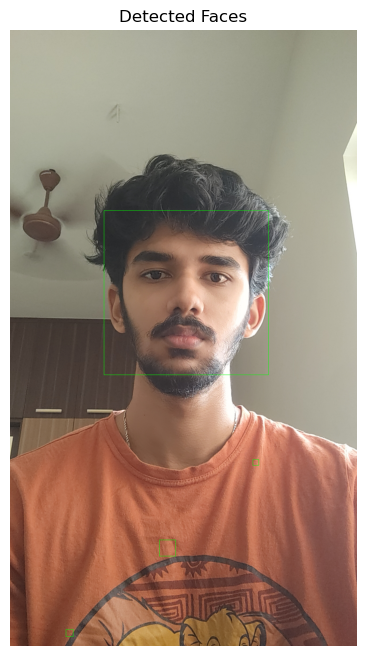

In [17]:
plt.figure(figsize=(8,8))
plt.imshow(result)
plt.title("Detected Faces")
plt.axis("off")
plt.show()

The Haar Cascade correctly detected my face but also produced three false positives on the printed design of my shirt. This occurred because the detector relies on Haar-like intensity patterns rather than semantic understanding of objects. Some high-contrast, symmetric regions in the shirt's design resembled facial features such as eyes and a mouth, causing the classifier to incorrectly identify them as faces.

In [30]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=20,
    minSize=(30, 30)
)

print("Faces Detected:", len(faces))

Faces Detected: 1


In [32]:
result = rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)

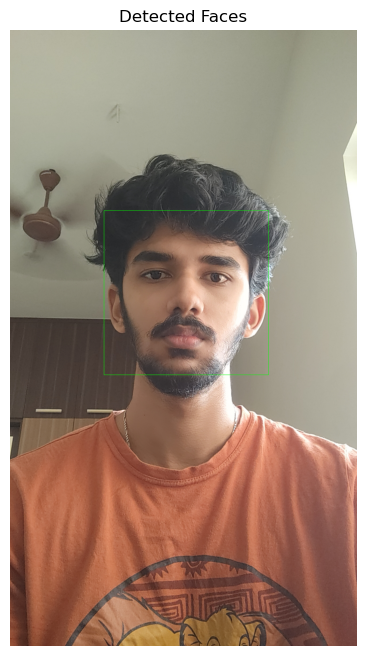

In [34]:
plt.figure(figsize=(8,8))
plt.imshow(result)
plt.title("Detected Faces")
plt.axis("off")
plt.show()